# Notebook 1: The AI-augmented alpha pipeline
### Workshop: AI in algorithmic trading | QuantInsti
##### Author: Vivek Krishnamoorthy
##### Last updated on: 9 April 2026
---
_Note: Code and structure drafted using Claude Sonnet 4.6 and Gemini 3; tested, revised, and validated by the author._

**Executive summary**

This notebook addresses a practical problem: most AI-generated trading code is subtly wrong in ways that are hard to spot. We walk through a series of steps: fetching raw market data, generating a multi-factor signal using a structured prompting framework, and running an automated audit that catches the most common errors (look-ahead bias, signal stagnation) before they distort a backtest. The final section provides a clean, vectorized backtest with standard performance metrics.

---
## Section 0: Environment setup

We use the below-mentioned Python libraries.

In [2]:
# --- Install dependencies (run once) ---
# !pip install yfinance pandas numpy matplotlib seaborn --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from datetime import datetime

# --- Plot aesthetics ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'monospace'
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Environment ready. Run date: {datetime.today().strftime('%Y-%m-%d')}")

Environment ready. Run date: 2026-04-08


---
## Section 1: Data setup

### 1.1 Fetching data

We use `yfinance` to download OHLCV data  for NiftyBEES (`NIFTYBEES.NS`) from 1 Jan 2020 to 2 April 2026. NiftyBEES is an exchange-traded fund (ETF) listed on NSE that tracks the Nifty 50 index - the Indian equity market equivalent of SPY for the S&P 500. NiftyBEES is suitable for retail trading; for institutional sizes, Nifty futures would be more appropriate. A few conventions we use here:

- **Adjusted Close** is used for all return calculations; this accounts for dividends and splits.
- We rename columns to lowercase and drop the multi-level index `yfinance` sometimes returns.

In [14]:
# ── Data Parameters ────────────────────────────────────────────────
TICKER      = 'NIFTYBEES.NS'
START_DATE  = '2020-01-01'
END_DATE    = '2026-04-02'

# ── Fetch ──────────────────────────────────────────────────────────
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

# Flatten multi-level columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

raw.columns = raw.columns.str.lower()
raw.index   = pd.to_datetime(raw.index)
raw         = raw.sort_index()

# ── Schema ─────────────────────────────────────────────────────────
# Column      | Type    | Description
# ------------|---------|--------------------------------------
# open        | float64 | Adjusted opening price
# high        | float64 | Adjusted daily high
# low         | float64 | Adjusted daily low
# close       | float64 | Adjusted closing price  ← primary series
# volume      | int64   | Daily share volume

print(f"Loaded {len(raw):,} trading days  |  {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Close index range: {raw['close'].min():.2f} - {raw['close'].max():.2f}")
raw.tail()

Loaded 1,547 trading days  |  2020-01-01 to 2026-04-01
Close index range: 83.52 - 297.55


Price,close,high,low,open,volume
Date,,,,,
2026-03-24,259.829987,261.500000,256.589996,259.000000,22805261
2026-03-25,264.059998,265.899994,255.899994,263.989990,14393659
2026-03-27,258.890015,265.200012,258.649994,265.100006,18765903
2026-03-30,253.440002,258.420013,252.550003,258.420013,27127660
2026-04-01,257.450012,260.070007,257.049988,258.339996,16273357


---
## Section 2: The prompt-to-code framework

### 2.1 Why prompting quality matters

The quality of AI-generated code depends on how well we prompt. A generic prompt like *"give me a trading strategy using RSI"* produces code that is technically correct but operationally suspect; it will almost certainly contain look-ahead bias, ignore transaction costs, have survivorship bias, etc.

The framework below is a **prompt template**. It forces the model to be explicit about constraints that matter in production, and it makes the output auditable.

---

### 2.2 A structured prompt template

```
ROLE:
You are a senior quantitative developer. You write production-quality Python
using pandas and numpy. You never introduce look-ahead bias.

TASK:
Generate a multi-factor signal combining:
  - RSI (14-period) on adjusted close
  - EMA crossover: 20-day EMA vs. 50-day EMA on adjusted close
  - Volume ratio: today's volume vs. 20-day rolling average volume

SIGNAL LOGIC:
  - LONG  (+1) when: RSI < 70 AND EMA_20 > EMA_50 AND volume_ratio > 1.0
  - SHORT (-1) when: RSI > 30 AND EMA_20 < EMA_50 AND volume_ratio > 1.0
  - FLAT  ( 0) otherwise

CONSTRAINTS:
  1. All signals must use .shift(1) to prevent look-ahead bias.
     The signal generated on day T uses only data available at the
     close of day T-1.
  2. All intermediate series must be named descriptively.
  3. Return a single pandas DataFrame column named 'signal'.
  4. Add an inline comment wherever look-ahead bias would be possible.
  5. Do NOT use any for-loops. Use only vectorized operations.

INPUT:
  - df: pandas DataFrame with columns [open, high, low, close, volume]
    indexed by DatetimeIndex

OUTPUT FORMAT:
  - A Python function: generate_signal(df) -> pd.Series
  - Docstring explaining each factor's role.
```

---

**Why makes this prompt more effective?**
It specifies the *role*, the *task*, the *logic*, the *constraints*, the *input schema*, and the *output format* in a single, unambiguous block. The model has little room to make assumptions that could silently break the code.

---
## Section 3: Signal generation

### 3.1 Multi-factor signal

Below is the code produced by the structured prompt (reviewed and approved by a human) template explained earlier. Each factor is calculated cleanly and the `.shift(1)` is applied once at the final step - a deliberate design choice that makes the audit layer's job straightforward.

**Factor rationale:**
- **RSI**: Filters for non-overbought conditions. We go long only when RSI < 70.
- **EMA crossover**: Trend filter. EMA_20 > EMA_50 indicates a positive near-term trend.
- **Volume ratio**: Participation filter. A volume ratio > 1.0 means today's volume is above its 20-day average - a sign that the move has conviction behind it.

In [16]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Compute Wilder's RSI using exponential moving averages of gains and losses.
    Returns a Series in [0, 100].
    """
    delta  = series.diff()
    gain   = delta.clip(lower=0)
    loss   = (-delta).clip(lower=0)
    # Wilder smoothing (equivalent to EWM with alpha = 1/period)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def generate_signal(df: pd.DataFrame) -> pd.Series:
    """
    Multi-factor signal combining RSI, EMA crossover, and volume.

    Factors
    -------
    rsi_14       : Momentum oscillator. Guards against buying into overbought rallies.
    ema_20       : Fast trend proxy.
    ema_50       : Slow trend proxy. Crossover defines regime.
    volume_ratio : Volume / 20d avg volume. Confirms move participation.

    Signal
    ------
    +1 : Long  - trend positive, not overbought, volume confirms
    -1 : Short - trend negative, not oversold, volume confirms
     0 : Flat  - conditions not met

    Look-ahead protection
    ----------------------
    All factors are computed on raw close/volume data, then .shift(1) is applied
    to the final signal. This ensures the signal used on trading day T is based
    entirely on data available at the market close of day T-1.
    """
    close  = df['close']
    volume = df['volume']

    # ── Factor 1: RSI ────────────────────────────────────────────────
    rsi_14 = compute_rsi(close, period=14)

    # ── Factor 2: EMA crossover ──────────────────────────────────────
    ema_20 = close.ewm(span=20, adjust=False).mean()
    ema_50 = close.ewm(span=50, adjust=False).mean()

    # ── Factor 3: Volume ratio ───────────────────────────────────────
    vol_avg_20   = volume.rolling(20).mean()
    volume_ratio = volume / vol_avg_20  # > 1.0 means above-average participation

    # ── Signal conditions (raw, before lag) ──────────────────────────
    long_cond  = (rsi_14 < 70)  & (ema_20 > ema_50) & (volume_ratio > 1.0)
    short_cond = (rsi_14 > 30)  & (ema_20 < ema_50) & (volume_ratio > 1.0)

    raw_signal = pd.Series(0, index=df.index, dtype=float)
    raw_signal[long_cond]  =  1.0
    raw_signal[short_cond] = -1.0

    # ── LOOK-AHEAD PROTECTION: shift signal by 1 day ─────────────────
    # The signal is produced at the close of day T-1 and executed at the
    # open of day T. .shift(1) enforces this temporal boundary.
    signal = raw_signal.shift(1).fillna(0)  # ← critical line

    return signal


# ── Apply signal ──────────────────────────────────────────────────
df = raw.copy()
df['signal'] = generate_signal(df)

# ── Also retain intermediate factors for audit ────────────────────
df['rsi_14']       = compute_rsi(df['close'], 14)
df['ema_20']       = df['close'].ewm(span=20, adjust=False).mean()
df['ema_50']       = df['close'].ewm(span=50, adjust=False).mean()
df['volume_ratio'] = df['volume'] / df['volume'].rolling(20).mean()

print(f"Signal value counts:\n{df['signal'].value_counts().to_string()}")
print(f"\nNaN count in signal: {df['signal'].isna().sum()}")
df[['close', 'rsi_14', 'ema_20', 'ema_50', 'volume_ratio', 'signal']].tail()

Signal value counts:
signal
 0.0    1069
 1.0     334
-1.0     144

NaN count in signal: 0


Price,close,rsi_14,ema_20,ema_50,volume_ratio,signal
Date,,,,,,
2026-03-24,259.829987,32.852429,270.778637,279.643359,1.511153,0.0
2026-03-25,264.059998,39.165475,270.138767,279.032247,0.932128,-1.0
2026-03-27,258.890015,34.852518,269.067457,278.242355,1.165723,0.0
2026-03-30,253.440002,30.979583,267.579128,277.269714,1.573225,-1.0
2026-04-01,257.450012,36.565143,266.614450,276.492471,0.922665,-1.0


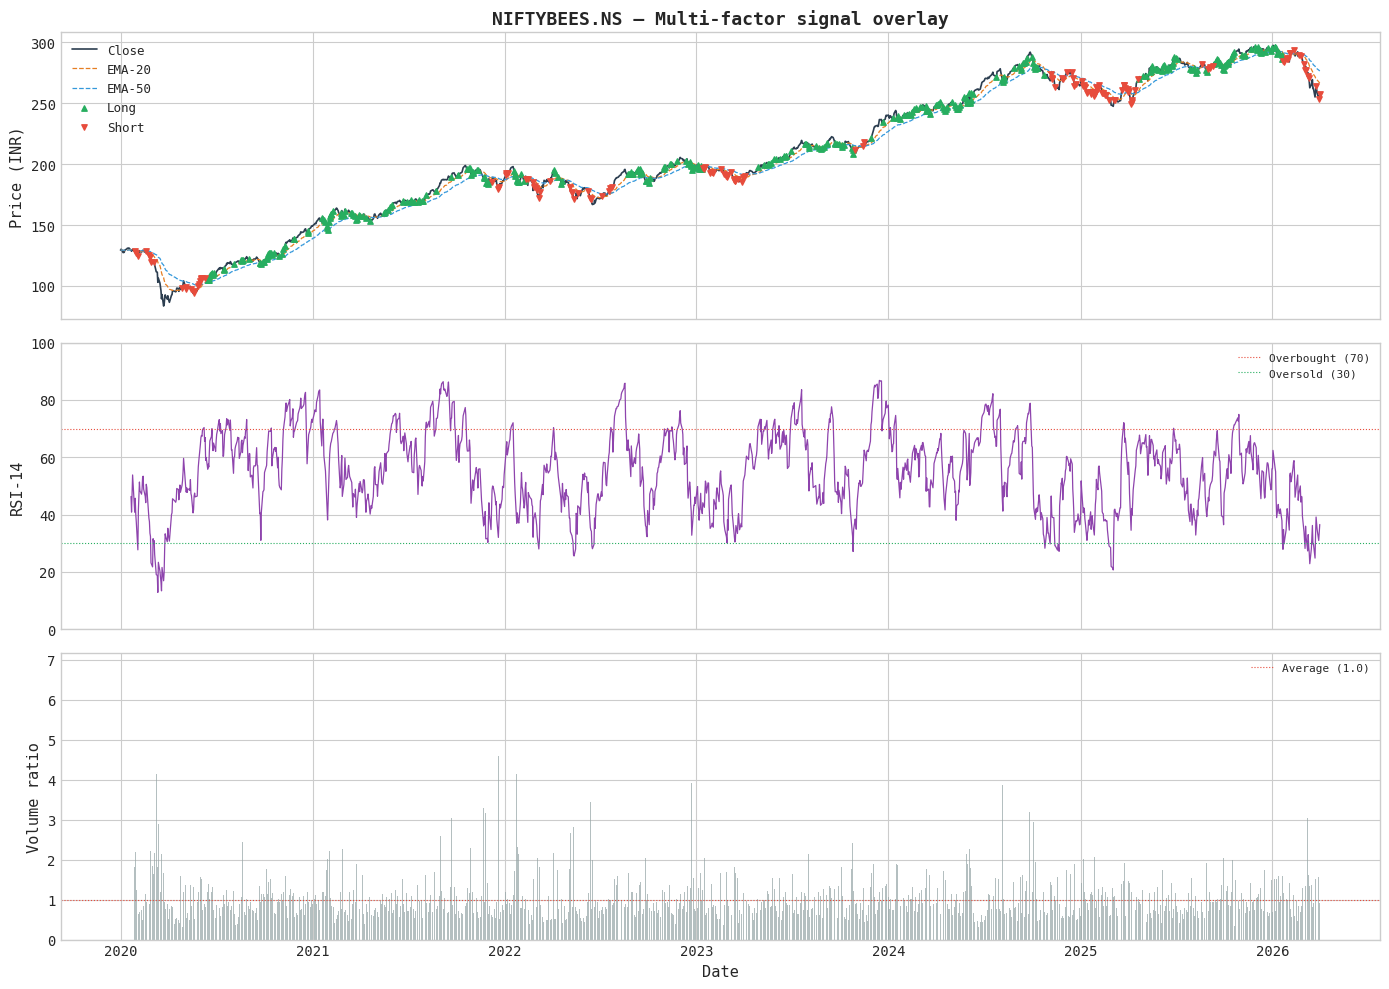

Signal overview chart saved.


In [17]:
# ── Visualize signal overlaid on price ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Price + EMAs + signal markers
ax1 = axes[0]
ax1.plot(df.index, df['close'],  color='#2c3e50', lw=1.2, label='Close')
ax1.plot(df.index, df['ema_20'], color='#e67e22', lw=0.9, ls='--', label='EMA-20')
ax1.plot(df.index, df['ema_50'], color='#3498db', lw=0.9, ls='--', label='EMA-50')

long_dates  = df.index[df['signal'] ==  1]
short_dates = df.index[df['signal'] == -1]
ax1.scatter(long_dates,  df.loc[long_dates,  'close'], marker='^', color='#27ae60', s=15, zorder=5, label='Long')
ax1.scatter(short_dates, df.loc[short_dates, 'close'], marker='v', color='#e74c3c', s=15, zorder=5, label='Short')
ax1.set_ylabel('Price (INR)')
ax1.set_title(f'{TICKER} — Multi-factor signal overlay', fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')

# Panel 2: RSI
ax2 = axes[1]
ax2.plot(df.index, df['rsi_14'], color='#8e44ad', lw=0.9)
ax2.axhline(70, color='#e74c3c', ls=':', lw=0.8, label='Overbought (70)')
ax2.axhline(30, color='#27ae60', ls=':', lw=0.8, label='Oversold (30)')
ax2.set_ylabel('RSI-14')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8)

# Panel 3: Volume ratio
ax3 = axes[2]
ax3.bar(df.index, df['volume_ratio'], color='#95a5a6', width=1, alpha=0.7)
ax3.axhline(1.0, color='#e74c3c', ls=':', lw=0.8, label='Average (1.0)')
ax3.set_ylabel('Volume ratio')
ax3.set_xlabel('Date')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/nb1_signal_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Signal overview chart saved.")

---
## Section 4: The audit layer

### 4.1 Why an automated audit?

AI-generated code fails in subtle ways. The two most dangerous failure modes in signal generation are:

1. **Look-ahead bias**: The signal uses future data. A backtest can look spectacular; live trading will look way worse. This happens when we forget to write `.shift(1)` on a signal derived from today's close, then entering a trade at that day itself before close - which is impossible.

2. **Signal persistence failure**: The signal never changes, or changes too rarely to be meaningful. This can indicate a logic error, an overly narrow condition, or a data issue.

The audit function below is not exhaustive, but it catches both failure modes automatically. You should run it on every signal you generate - AI-produced or otherwise.

In [18]:
def audit_signal(df: pd.DataFrame,
                 signal_col: str = 'signal',
                 raw_signal_col: str = None,
                 max_flat_run_pct: float = 0.10,
                 min_transition_pct: float = 0.01) -> dict:
    """
    Programmatically audit a trading signal for common errors.

    Checks
    ------
    1. Look-ahead bias proxy: verifies that the signal column is lagged
       relative to a raw (unshifted) signal, if provided.
    2. Signal persistence: checks that the signal is not flat for more
       than `max_flat_run_pct` of the sample as a single continuous run.
    3. Transition frequency: verifies that signal changes (entries/exits)
       occur on at least `min_transition_pct` of all trading days.
    4. NaN audit: flags any NaN values in the signal.
    5. Value domain: confirms signal values are in {-1, 0, +1}.

    Returns
    -------
    A dict of results. 'passed' is False if any critical check fails.
    """
    signal = df[signal_col].copy()
    n      = len(signal)
    results = {}
    passed  = True

    # ── Check 1: NaN audit ────────────────────────────────────────────
    nan_count = signal.isna().sum()
    nan_ok    = nan_count == 0
    if not nan_ok:
        passed = False
    results['nan_check'] = {
        'passed'    : nan_ok,
        'nan_count' : int(nan_count),
        'note'      : 'CRITICAL: NaN values in signal will cause incorrect returns.' if not nan_ok else 'OK'
    }

    # ── Check 2: Value domain ─────────────────────────────────────────
    unique_vals = set(signal.dropna().unique())
    valid_vals  = {-1.0, 0.0, 1.0}
    domain_ok   = unique_vals.issubset(valid_vals)
    if not domain_ok:
        passed = False
    results['domain_check'] = {
        'passed'      : domain_ok,
        'found_values': sorted(unique_vals),
        'note'        : f'Unexpected values: {unique_vals - valid_vals}' if not domain_ok else 'OK'
    }

    # ── Check 3: Look-ahead bias proxy ───────────────────────────────
    if raw_signal_col and raw_signal_col in df.columns:
        raw    = df[raw_signal_col]
        lagged = raw.shift(1)
        # If signal == lagged (shifted by 1), look-ahead is correctly handled
        match  = (signal == lagged).mean()
        lag_ok = match > 0.95  # Allow for small discrepancy due to NaN edges
        if not lag_ok:
            passed = False
        results['lookahead_check'] = {
            'passed'         : lag_ok,
            'lag_match_rate' : round(float(match), 4),
            'note'           : 'CRITICAL: Signal does not appear to be correctly lagged.' if not lag_ok else 'OK — signal matches 1-period lag of raw signal.'
        }
    else:
        # Structural proxy: check if signal could correlate with same-day returns
        # A high positive correlation of today's signal with today's return is a red flag
        if 'close' in df.columns:
            today_return  = df['close'].pct_change()
            corr          = signal.corr(today_return)
            # A correlation > 0.15 warrants scrutiny (heuristic, not definitive)
            lag_ok        = abs(corr) < 0.15
            results['lookahead_check'] = {
                'passed'                  : lag_ok,
                'signal_sameday_ret_corr' : round(float(corr), 4),
                'note'                    : ('WARNING: High correlation with same-day return. Investigate for look-ahead bias.'
                                             if not lag_ok else 'OK — low correlation with same-day return (heuristic proxy only).')
            }
            if not lag_ok:
                passed = False

    # ── Check 4: Signal persistence (max flat run) ───────────────────
    flat_signal       = (signal == 0).astype(int)
    flat_runs         = flat_signal.groupby((flat_signal != flat_signal.shift()).cumsum()).transform('sum')
    max_flat_run      = int(flat_runs.max())
    max_run_pct       = max_flat_run / n
    persistence_ok    = max_run_pct <= max_flat_run_pct
    if not persistence_ok:
        passed = False
    results['persistence_check'] = {
        'passed'       : persistence_ok,
        'max_flat_run' : max_flat_run,
        'max_flat_pct' : round(max_run_pct * 100, 2),
        'threshold_pct': max_flat_run_pct * 100,
        'note'         : (f'CRITICAL: Signal is flat for {max_flat_run} consecutive days ({max_run_pct*100:.1f}% of sample).'
                          if not persistence_ok else 'OK')
    }

    # ── Check 5: Transition frequency ────────────────────────────────
    transitions     = (signal != signal.shift()).sum()
    transition_pct  = transitions / n
    transition_ok   = transition_pct >= min_transition_pct
    if not transition_ok:
        passed = False
    results['transition_check'] = {
        'passed'         : transition_ok,
        'transitions'    : int(transitions),
        'transition_pct' : round(transition_pct * 100, 2),
        'threshold_pct'  : min_transition_pct * 100,
        'note'           : ('CRITICAL: Signal transitions too infrequently — check logic conditions.'
                            if not transition_ok else 'OK')
    }

    results['overall_passed'] = passed
    return results


# ── Run the audit ─────────────────────────────────────────────────
audit_results = audit_signal(df, signal_col='signal')

print("=" * 60)
print(" SIGNAL AUDIT REPORT")
print("=" * 60)
for check_name, detail in audit_results.items():
    if check_name == 'overall_passed':
        continue
    status = '✅ PASS' if detail['passed'] else '❌ FAIL'
    print(f"\n[{check_name.upper()}]  {status}")
    for k, v in detail.items():
        if k != 'passed':
            print(f"  {k:<30}: {v}")

print("\n" + "=" * 60)
overall = audit_results['overall_passed']
print(f" OVERALL: {'✅ ALL CHECKS PASSED' if overall else '❌ AUDIT FAILED — DO NOT BACKTEST'}")
print("=" * 60)

 SIGNAL AUDIT REPORT

[NAN_CHECK]  ✅ PASS
  nan_count                     : 0
  note                          : OK

[DOMAIN_CHECK]  ✅ PASS
  found_values                  : [-1.0, 0.0, 1.0]
  note                          : OK

[LOOKAHEAD_CHECK]  ✅ PASS
  signal_sameday_ret_corr       : 0.0447
  note                          : OK — low correlation with same-day return (heuristic proxy only).

[PERSISTENCE_CHECK]  ✅ PASS
  max_flat_run                  : 32
  max_flat_pct                  : 2.07
  threshold_pct                 : 10.0
  note                          : OK

[TRANSITION_CHECK]  ✅ PASS
  transitions                   : 493
  transition_pct                : 31.87
  threshold_pct                 : 1.0
  note                          : OK

 OVERALL: ✅ ALL CHECKS PASSED


---
## Section 5: Vectorized backtest

### 5.1 Design principles

A few non-negotiable rules for a clean backtest:

1. **Preferably use log returns, not simple returns.** Log returns are additive across time, which simplifies cumulative performance calculations and avoids compounding errors. If you use simple returns, be careful about cumulative performance calculations.
2. **Signal is the position held for the day.** Since our signal is generated at T-1's close and executed at T's open, it represents the *position held during day T*.
3. **Transaction costs are applied at each trade.** We use a simple flat cost per trade here; Notebook 2 introduces a more realistic slippage model.
4. **No lookahead in returns.** The daily return on day T is `ln (close_T / close_{T-1})`. We multiply this by the signal in effect on day T.

In [19]:
def run_backtest(df: pd.DataFrame,
                 signal_col: str    = 'signal',
                 cost_per_trade_bps: float = 20.0) -> pd.DataFrame:
    """
    Vectorized backtest engine.

    Parameters
    ----------
    df                : DataFrame with 'close' and signal column
    signal_col        : Column name of the signal (+1, 0, -1)
    cost_per_trade_bps: Round-trip transaction cost in basis points

    Returns
    -------
    bt: DataFrame with daily returns, strategy returns, and cumulative series.
    """
    bt = df[['close', signal_col]].copy().rename(columns={signal_col: 'signal'})

    # ── Daily log returns of the underlying ───────────────────────────
    bt['log_ret'] = np.log(bt['close'] / bt['close'].shift(1))

    # ── Strategy log returns ──────────────────────────────────────────
    # signal_t * log_ret_t: position held during day T × return during day T
    bt['strat_ret_gross'] = bt['signal'] * bt['log_ret']

    # ── Transaction costs ─────────────────────────────────────────────
    # A trade occurs whenever the signal changes. Cost = bps / 10,000.
    cost_decimal       = cost_per_trade_bps / 10_000
    bt['trade']        = (bt['signal'] != bt['signal'].shift(1)).astype(int)
    bt['cost']         = bt['trade'] * cost_decimal
    bt['strat_ret_net'] = bt['strat_ret_gross'] - bt['cost']

    # ── Cumulative performance ────────────────────────────────────────
    bt['cum_bh']        = bt['log_ret'].cumsum().apply(np.exp)         # Buy-and-hold
    bt['cum_strat']     = bt['strat_ret_net'].cumsum().apply(np.exp)   # Strategy

    # Normalize to 1.0 at start
    bt['cum_bh']    = bt['cum_bh']    / bt['cum_bh'].iloc[1]
    bt['cum_strat'] = bt['cum_strat'] / bt['cum_strat'].iloc[1]

    return bt.dropna()


bt = run_backtest(df, cost_per_trade_bps=20.0)
print(f"Backtest rows: {len(bt):,}  |  Trades executed: {int(bt['trade'].sum()):,}")
bt[['log_ret', 'signal', 'strat_ret_gross', 'cost', 'strat_ret_net']].tail()

Backtest rows: 1,546  |  Trades executed: 492


Price,log_ret,signal,strat_ret_gross,cost,strat_ret_net
Date,,,,,
2026-03-24,0.018176,0.0,0.000000,0.000,0.000000
2026-03-25,0.016149,-1.0,-0.016149,0.002,-0.018149
2026-03-27,-0.019773,0.0,-0.000000,0.002,-0.002000
2026-03-30,-0.021276,-1.0,0.021276,0.002,0.019276
2026-04-01,0.015698,-1.0,-0.015698,0.000,-0.015698


---
## Section 6: Performance metrics

### 6.1 Why these three metrics?

- **Sharpe ratio**: The canonical risk-adjusted return measure. A ratio above 1.0 is reasonable; above 2.0 in live trading deserves scrutiny. We annualize using 252 trading days.
- **CAGR (Compound annual growth rate)**: The actual annualized return. Unlike arithmetic mean return, it accounts for the drag of volatility on compounding.
- **Maximum drawdown**: The largest peak-to-trough decline. This number tells you whether real investors will stay in the strategy or redeem. A strategy with a 40% max drawdown is theoretically profitable but practically undeployable.

In [20]:
def compute_metrics(returns: pd.Series,
                    cum_series: pd.Series,
                    trading_days_per_year: int = 252) -> dict:
    """
    Compute Sharpe ratio, CAGR, and Maximum drawdown from log returns.

    Parameters
    ----------
    returns               : Daily log returns series
    cum_series            : Cumulative performance series (starting at 1.0)
    trading_days_per_year : Annualization factor (default 252)

    Returns
    -------
    dict with sharpe, cagr, max_drawdown, win_rate
    """
    n_years = len(returns) / trading_days_per_year

    # CAGR: terminal value ^ (1/years) - 1
    final_val  = cum_series.iloc[-1]
    cagr       = (final_val ** (1 / n_years)) - 1

    # Sharpe: annualized mean / annualized std of log returns
    mean_daily = returns.mean()
    std_daily  = returns.std()
    sharpe     = (mean_daily / std_daily) * np.sqrt(trading_days_per_year) if std_daily > 0 else np.nan

    # Maximum drawdown
    rolling_max   = cum_series.cummax()
    drawdown      = (cum_series - rolling_max) / rolling_max
    max_drawdown  = drawdown.min()  # most negative value

    # Win rate (fraction of days with positive return)
    win_rate = (returns > 0).sum() / (returns != 0).sum()

    return {
        'CAGR'          : round(cagr       * 100, 2),
        'Sharpe ratio'  : round(sharpe,            3),
        'Max drawdown'  : round(max_drawdown * 100, 2),
        'Win rate (%)'  : round(win_rate    * 100, 2),
        'Total return %': round((final_val - 1) * 100, 2)
    }


# ── Compute for strategy and benchmark ────────────────────────────
strat_metrics = compute_metrics(bt['strat_ret_net'], bt['cum_strat'])
bh_metrics    = compute_metrics(bt['log_ret'],       bt['cum_bh'])

metrics_df = pd.DataFrame({
    'Buy & hold' : bh_metrics,
    'Strategy'   : strat_metrics
}).T

print("\n" + "=" * 50)
print(" PERFORMANCE METRICS")
print("=" * 50)
print(metrics_df.to_string())
print("=" * 50)


 PERFORMANCE METRICS
             CAGR  Sharpe ratio  Max drawdown  Win rate (%)  Total return %
Buy & hold  11.76         0.693        -36.34         54.58           97.83
Strategy    -8.01        -0.929        -54.46         32.32          -40.09


The strategy underperforms a passive buy-and-hold by ~20 percentage points in CAGR - a direct consequence of signal quality, trading frequency, and transaction costs. This is the expected outcome of an unrefined, AI-generated strategy and the motivation for the workflow in Notebook 2.

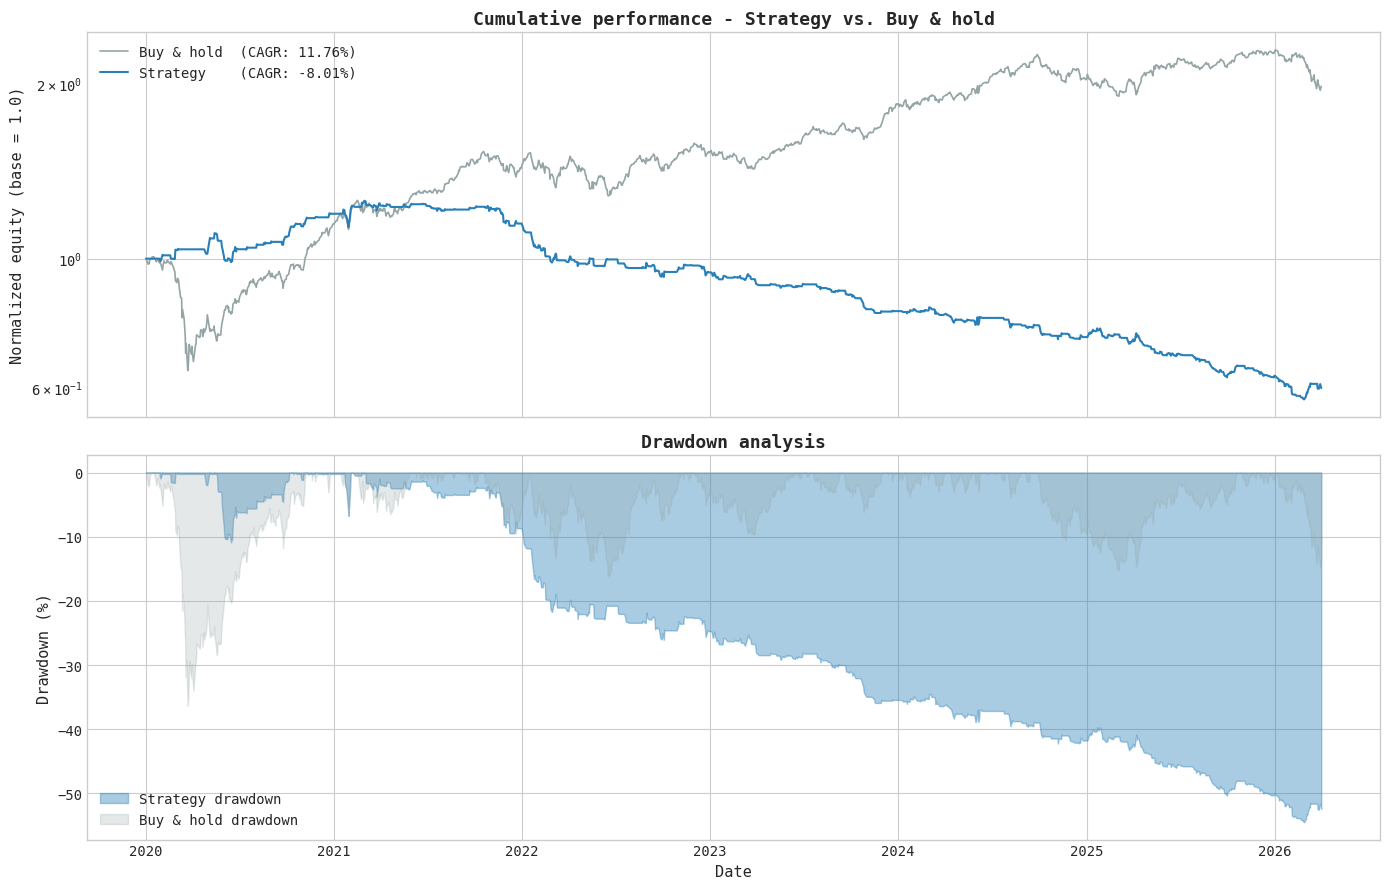

Backtest results chart saved.


In [22]:
# ── Visualize backtest results ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1: Cumulative performance
ax1 = axes[0]
ax1.plot(bt.index, bt['cum_bh'],    color='#95a5a6', lw=1.2, label=f'Buy & hold  (CAGR: {bh_metrics["CAGR"]}%)')
ax1.plot(bt.index, bt['cum_strat'], color='#2980b9', lw=1.5, label=f'Strategy    (CAGR: {strat_metrics["CAGR"]}%)')
ax1.set_ylabel('Normalized equity (base = 1.0)')
ax1.set_title('Cumulative performance - Strategy vs. Buy & hold', fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_yscale('log')

# Panel 2: Drawdown
ax2 = axes[1]
rolling_max_strat = bt['cum_strat'].cummax()
drawdown_strat    = (bt['cum_strat'] - rolling_max_strat) / rolling_max_strat * 100

rolling_max_bh    = bt['cum_bh'].cummax()
drawdown_bh       = (bt['cum_bh'] - rolling_max_bh) / rolling_max_bh * 100

ax2.fill_between(bt.index, drawdown_strat, 0, color='#2980b9', alpha=0.4, label='Strategy drawdown')
ax2.fill_between(bt.index, drawdown_bh,    0, color='#95a5a6', alpha=0.25, label='Buy & hold drawdown')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.set_title('Drawdown analysis', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/nb1_backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Backtest results chart saved.")

---
## Section 7: Summary and limitations

### What this notebook demonstrated

- A structured prompting workflow that produces auditable code.
- An automated audit layer that catches look-ahead bias and signal persistence failures before a backtest runs.
- A clean, vectorized backtest with standard performance metrics.

### What this notebook deliberately did not address

1. **Position sizing**: We used a fixed ±1 position. In practice, position size is a function of volatility, conviction, and portfolio constraints. Notebook 2 addresses this via ATR-based volatility targeting.
2. **Realistic friction**: The 20 bps transaction cost is a simplification.  Real costs include bid-ask spread, market impact, and statutory charges. Notebook 2 implements a two-tier cost model and compares gross and net returns explicitly.
3. **Regime sensitivity**: The strategy is a single set of rules applied uniformly. Notebook 2 introduces deterministic circuit breakers that respond to drawdown and volatility regimes.
4. **Overfitting risk**: We have not applied any out-of-sample testing, walk-forward validation, or parameter stability analysis. These remain open - they are flagged in Notebook 2 but not resolved in this workshop.

A backtest that passes the audit layer is *necessary* but not *sufficient* for deployment. It is the beginning of due diligence, not the end.